In [19]:
from typing_extensions import TypedDict
#defining the state structure which is like a shared memory flows throughout the workflow and this state is 
#updated accordingly when passes through the nodes 
class State(TypedDict):
    graph_info: str     

In [20]:
#creating the nodes(the functions)
def start_play(state:State):
    print("Start Play node has been called ")
    return{"graph_info":state["graph_info"]+"I am planning to play"}

def Cricket(state: State):
    print("Cricket node has been called")
    return{"graph_info":state["graph_info"]+"Cricket"}

def Badminton(state:State):
    print("badminton node has been called")
    return {"graph_info":state["graph_info"]+"Badminton"}

In [23]:
import random
from typing import Literal 
def random_play(state:State)->Literal['Cricket','Badminton']:
    if random.random()>0.5:
        return "Cricket"
    else:
        return "Badminton"
    

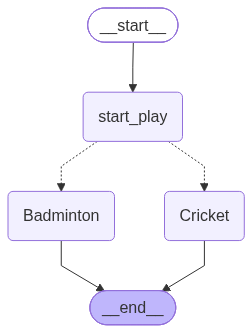

Start Play node has been called 
Cricket node has been called


{'graph_info': 'My name is ShrxI am planning to playCricket'}

In [ ]:
from langgraph.graph import StateGraph,START,END
from IPython.display import Image,display
 #first we  initialize the state of graph 
graph=StateGraph(State)
#add all the nodes 
graph.add_node("start_play",start_play)
graph.add_node("Cricket",Cricket)
graph.add_node("Badminton",Badminton)

#schedule the flow of the graph
graph.add_edge(START,"start_play")
graph.add_conditional_edges("start_play",random_play)
graph.add_edge("Cricket",END)
graph.add_edge("Badminton",END)
## compiling the graph
graph_builder=graph.compile()
##visualize 
display(Image(graph_builder.get_graph().draw_mermaid_png()))
graph_builder.invoke({"graph_info":"My name is Shrx "})